The Iris dataset, introduced by Ronald Fisher in his 1936 paper The Use of Multiple Measurements in Taxonomic Problems, is a well-known example of linear discriminant analysis. Often referred to as Anderson's Iris dataset, the data was collected by Edgar Anderson to examine the morphological variation of Iris flowers across three species: Iris setosa, Iris virginica, and Iris versicolor. Two species were gathered from the same pasture in the Gaspé Peninsula, all measured under consistent conditions.

The dataset includes 50 samples from each species, with four features measured: sepal length, sepal width, petal length, and petal width (in centimeters). Fisher used these features to develop a linear discriminant model for species classification.

# Google Colab Path Note

If you run this notebook in Google Colab, mount Google Drive first:

```python
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/UCI/UCI_427.62_Python_for_Data_Analysis'
DATA_DIR = f'{BASE_DIR}/05_Datasets'
ASSIGNMENTS_DIR = f'{BASE_DIR}/04_Assignments'
OUTPUTS_DIR = f'{BASE_DIR}/04_Assignments/Outputs'
```

If you run locally in Jupyter/Anaconda, do not use `/content/drive`; use relative paths such as `../05_Datasets/...`.
The Mac path `/Users/yuzhang/.../My Drive/...` is only for local file browsing and is not a Colab path.


![https://miro.medium.com/max/2550/0*GVjzZeYrir0R_6-X.png](https://miro.medium.com/max/2550/0*GVjzZeYrir0R_6-X.png)

source image:https://miro.medium.com/max/2550/0*GVjzZeYrir0R_6-X.png

This study we try to clustering Iris Dataset used Kmeans

[Attribute Information:
](https://archive.ics.uci.edu/ml/datasets/iris)
1. sepal length in cm
2. sepal width in cm
3. petal length in cm
4. petal width in cm
5. class:
-- Iris Setosa
-- Iris Versicolour
-- Iris Virginica

import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# from sklearn.preprocessing import MinMaxScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


reading dataset

In [ ]:
iris = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/UCI/UCI_427.62_Python_for_Data_Analysis/05_Datasets/M5_iris.csv")
x = iris.iloc[:, [0, 1, 2, 3]].values

In [ ]:
iris.info()
iris[0:10]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [ ]:
#Frequency distribution of species"
iris_outcome = pd.crosstab(index=iris["species"],  # Make a crosstab
                              columns="count")      # Name the count column

iris_outcome

col_0,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
iris_setosa=iris.loc[iris["species"]=="Iris-setosa"]
iris_virginica=iris.loc[iris["species"]=="Iris-virginica"]
iris_versicolor=iris.loc[iris["species"]=="Iris-versicolor"]

**Distribution plots
**

plot each flower to a histogram

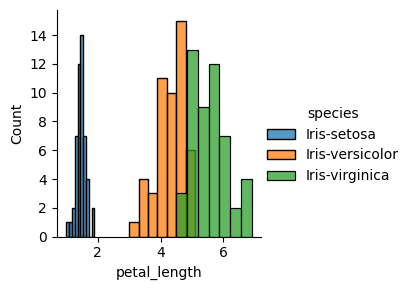

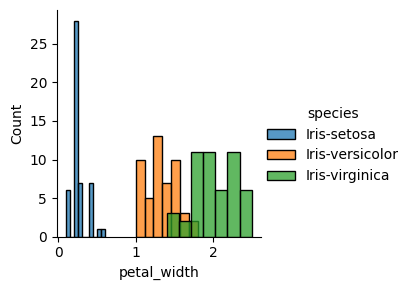

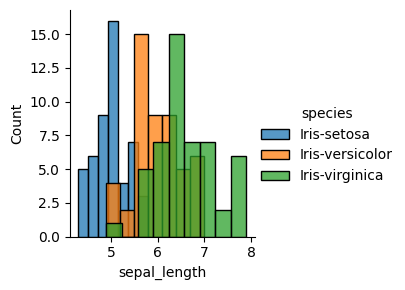

In [ ]:
sns.FacetGrid(iris,hue="species").map(sns.histplot,"petal_length").add_legend()
sns.FacetGrid(iris,hue="species").map(sns.histplot,"petal_width").add_legend()
sns.FacetGrid(iris,hue="species").map(sns.histplot,"sepal_length").add_legend()
plt.show()

box plot

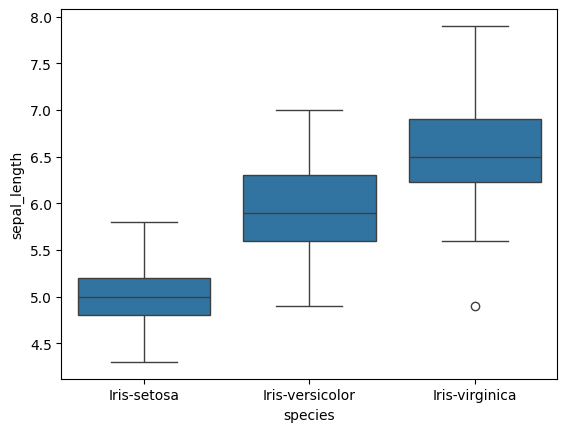

In [ ]:
sns.boxplot(x="species",y="sepal_length",data=iris)
plt.show()

violin plot

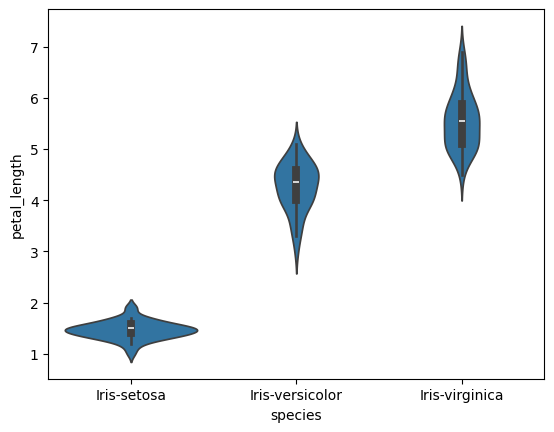

In [ ]:
sns.violinplot(x="species",y="petal_length",data=iris)
plt.show()

**Scatter plot**


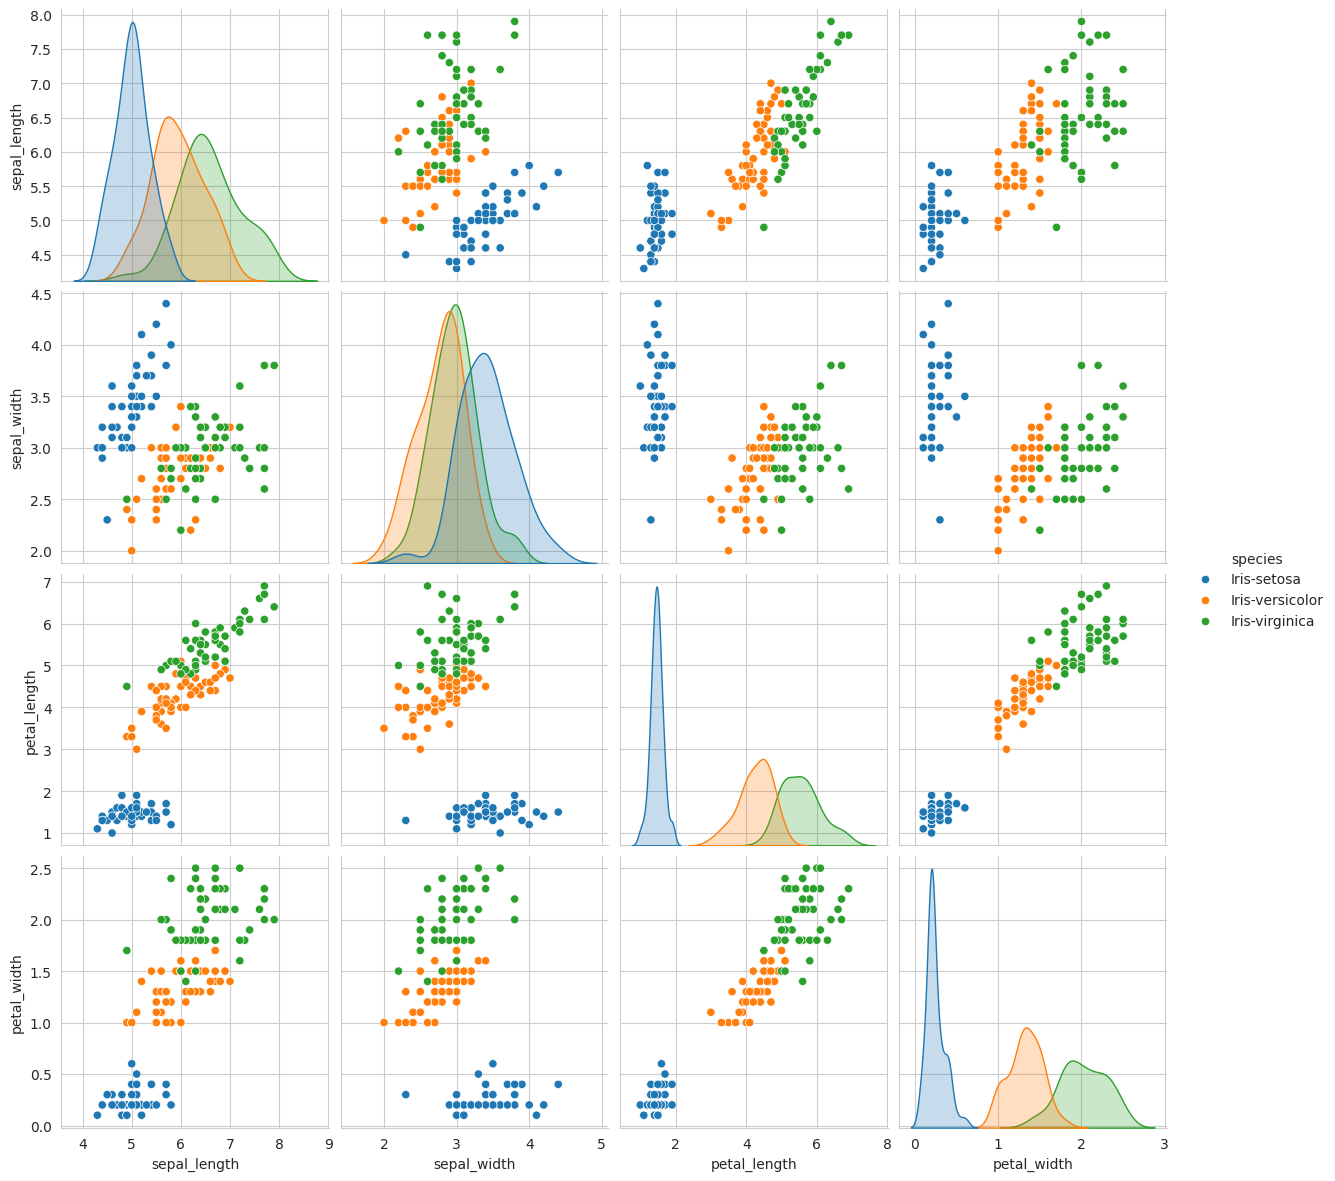

In [ ]:
sns.set_style("whitegrid")
sns.pairplot(iris,hue="species",height=3);
plt.show()

# K-Means

[K-means](http://https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/) is a centroid-based algorithm, or a distance-based algorithm, where we calculate the distances to assign a point to a cluster. In K-Means, each cluster is associated with a centroid.

### Implementing K-Means Clustering: Step-by-Step Process

1. **Choosing the Number of Clusters (k):**  
   The first step in implementing K-Means clustering is selecting the number of clusters, denoted as *k*. This is a critical decision, as it determines how the data will be grouped. Various methods, such as the Elbow Method, can be used to help choose an optimal value for *k* based on the data's characteristics.

2. **Initializing the Centroids:**  
   Next, we randomly select *k* data points from the dataset to serve as the initial centroids of the clusters. These centroids act as the starting points for the clusters. They are essentially the "representatives" of each cluster at the beginning of the process.

3. **Assigning Data Points to the Nearest Centroid:**  
   After initializing the centroids, we assign each data point in the dataset to the nearest centroid based on a distance metric, usually Euclidean distance. Each data point will belong to the cluster whose centroid is closest, forming temporary clusters.

4. **Recomputing the Centroids:**  
   Once all the points are assigned to clusters, we update the centroids. The new centroid of each cluster is calculated by taking the mean of all the data points assigned to that cluster. This new centroid represents the "center" of the points in the cluster.

5. **Repeating the Process:**  
   Steps 3 and 4 are repeated iteratively: data points are reassigned to the nearest centroids, and new centroids are computed based on the updated clusters. This process continues until the centroids no longer change significantly, or a predefined number of iterations is reached, indicating convergence.

By the end of these iterations, the algorithm has grouped the data into *k* clusters, with each point assigned to the cluster whose centroid is closest. The result is a partitioned dataset where similar data points are grouped together.

In [ ]:
#Finding the optimum number of clusters for k-means classification
from sklearn.cluster import KMeans
wcss = []

for i in range(2, 6):
    kmeans = KMeans(n_clusters = i, init = 'k-means++')
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

### Using the Elbow Method to Determine the Optimal Number of Clusters for K-Means Clustering

The Elbow Method is a popular technique in data science to identify the optimal number of clusters, *k*, for K-Means clustering. The goal is to choose the value of *k* that minimizes the within-cluster sum of squares (WCSS), while also avoiding too many clusters that overfit the data. Here's a step-by-step breakdown of the process:

1. **Run K-Means for Different Values of k:**
   Start by running the K-Means clustering algorithm on the dataset for a range of *k* values. Typically, we test a range of values, such as 1 to 10 or 1 to 15, depending on the dataset’s size and complexity. For each *k*, the K-Means algorithm will assign points to clusters and calculate the WCSS, which represents the sum of squared distances between each point and its cluster centroid.

2. **Plot the WCSS Against k:**
   After running K-Means for different *k* values, plot the WCSS values on the y-axis and the corresponding *k* values on the x-axis. The resulting graph will typically show a steep decrease in WCSS as the number of clusters increases, followed by a point where the rate of decrease slows down significantly. This "bend" or "elbow" in the plot indicates the optimal number of clusters.

3. **Interpret the Elbow Point:**
   The "elbow" is the point on the graph where adding more clusters doesn’t result in a significant reduction in WCSS. This suggests that increasing *k* beyond this point doesn’t provide much additional benefit in terms of better fitting the data. The value of *k* at this elbow point is considered the optimal number of clusters for the data.

4. **Final Cluster Selection:**
   Based on the elbow point, you can select the optimal *k* and rerun the K-Means algorithm with that number of clusters. The final clusters should provide a good balance between being compact (low WCSS) and generalizable (avoiding overfitting).

By using the Elbow Method, you can ensure that you choose a suitable number of clusters for your data, leading to a more meaningful and interpretable clustering result.

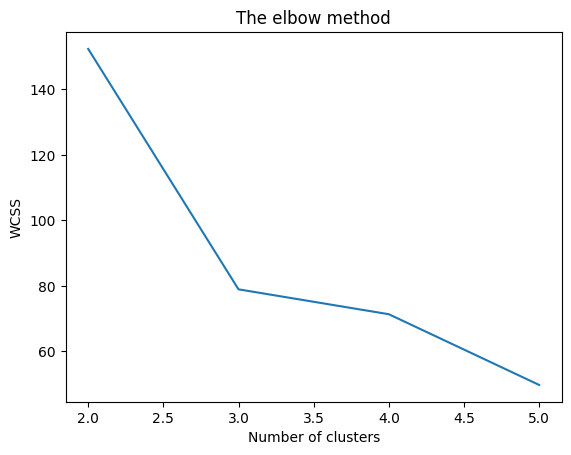

In [ ]:
plt.plot(range(2, 6), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') #within cluster sum of squares
plt.show()

# Implementing K-Means Clustering


In [ ]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_kmeans = kmeans.fit_predict(x)

In [ ]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_kmeans4 = kmeans.fit_predict(x)

In [ ]:
print(y_kmeans)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [ ]:
print(y_kmeans4)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 0 3 0 3 0 3 0 0 0 0 3 0 3 0 0 3 0 3 0 3 3
 3 3 3 3 3 0 0 0 0 3 0 3 3 3 0 0 0 3 0 0 0 0 0 3 0 0 2 3 2 2 2 2 0 2 2 2 3
 3 2 3 3 2 2 2 2 3 2 3 2 3 2 2 3 3 2 2 2 2 2 3 3 2 2 2 3 2 2 2 3 2 2 2 3 3
 2 3]


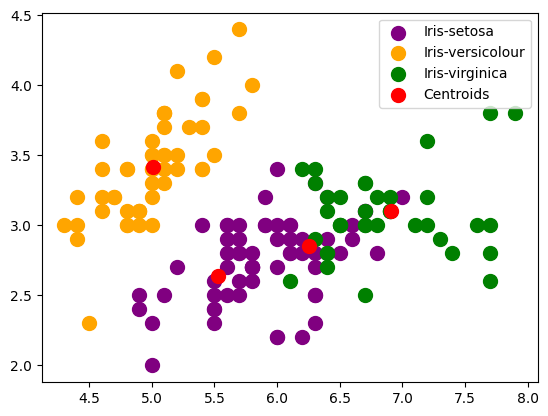

In [ ]:
#Visualising the clusters
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s = 100, c = 'purple', label = 'Iris-setosa')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s = 100, c = 'orange', label = 'Iris-versicolour')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Iris-virginica')

#Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], s = 100, c = 'red', label = 'Centroids')

plt.legend()

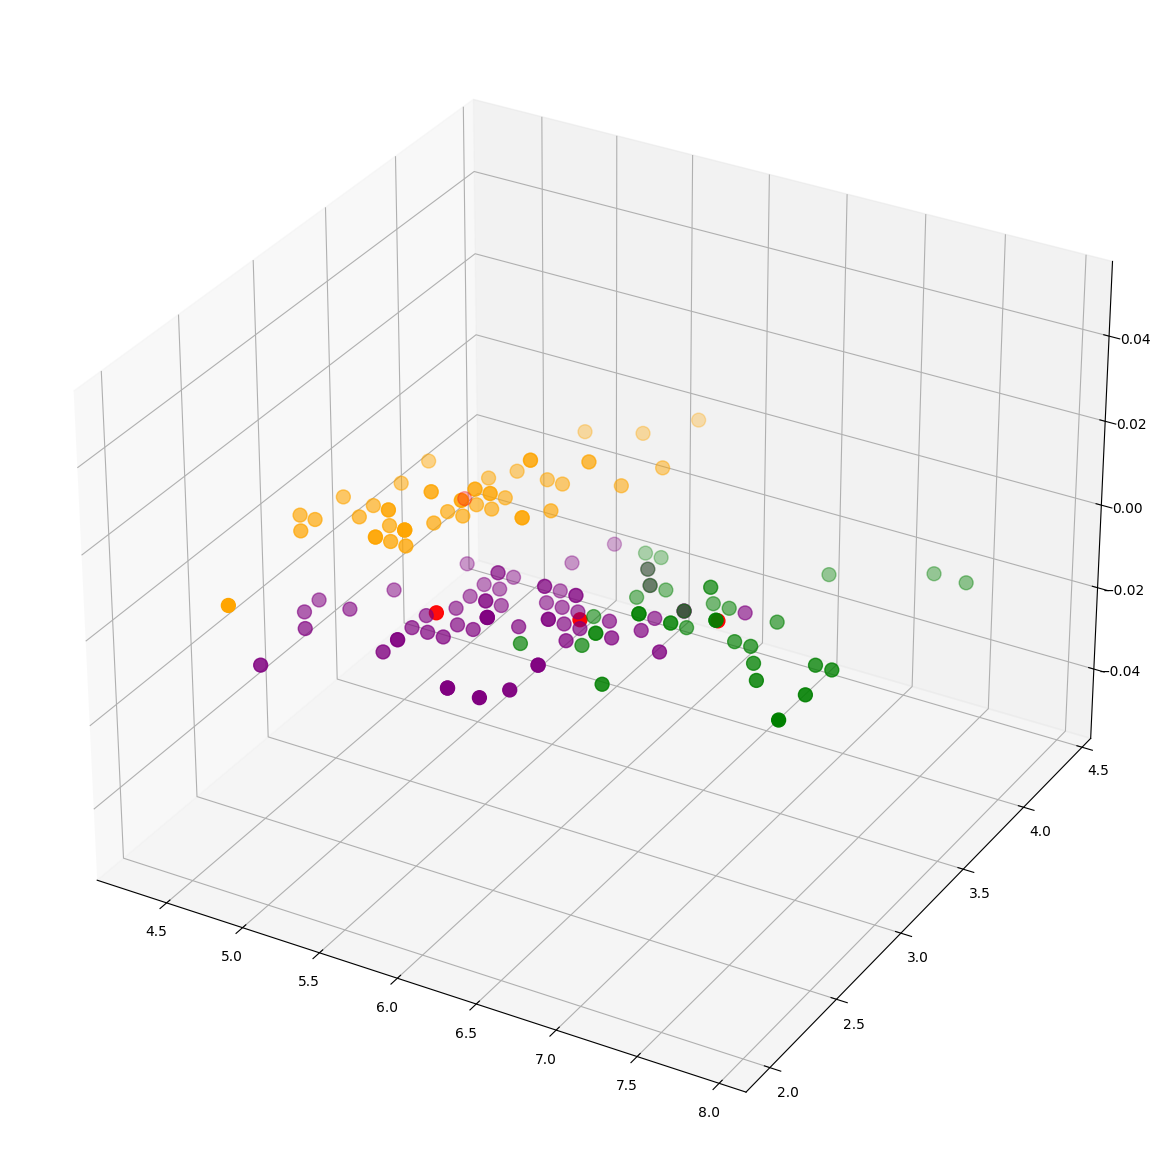

In [ ]:
# 3d scatterplot using matplotlib

fig = plt.figure(figsize = (15,15))
ax = fig.add_subplot(111, projection='3d')
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s = 100, c = 'purple', label = 'Iris-setosa')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s = 100, c = 'orange', label = 'Iris-versicolour')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Iris-virginica')

#Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], s = 100, c = 'red', label = 'Centroids')
plt.show()

## research the centroid analysis, when K = 3, for both D-2 and D-3 scatter plots, there are found four centroid and why?

### Experimenting with Principal Component Analysis (PCA): Intuition, Theory, and Applications

Principal Component Analysis (PCA) is one of the most widely used and intuitive methods for dimensionality reduction. It involves projecting high-dimensional data onto a lower-dimensional orthogonal subspace, helping to simplify complex datasets while retaining as much of the original variance as possible.

The underlying idea behind PCA is that all data points can be represented as an ellipsoid in a subspace of the original feature space. The axes of this ellipsoid correspond to the principal components, which are aligned with the directions of maximum variance in the data. By assuming that the data lies in a subspace of lower dimension, we can reduce the dimensionality of the data by removing highly correlated features, as the principal components (basis vectors) are orthogonal to one another. This allows for efficient data compression and noise reduction.

In the general case, the dimensionality of the resulting ellipsoid matches the original feature space. However, the key insight of PCA is that data often lies in a subspace of much lower dimensionality, which allows us to discard the "excess" or redundant dimensions. PCA does this by greedily selecting each principal component based on where the data exhibits the most variance, starting with the direction of maximum dispersion and iteratively moving to the next direction of greatest variance.

As noted by Geoffrey Hinton, "To deal with hyper-planes in a 14-dimensional space, visualize a 3D space and say 'fourteen' very loudly. Everyone does it." This highlights the challenge of visualizing high-dimensional spaces, which PCA helps to mitigate by reducing the complexity of the data while preserving its essential structure.

More broadly, observations in a dataset can be thought of as points forming an ellipsoid within a subspace of the original feature space. The new basis vectors in this subspace are aligned with the axes of the ellipsoid, where each axis represents a principal component. This alignment allows us to remove highly correlated features, as the principal components are orthogonal to one another.

In the general case, the dimensionality of the resulting ellipsoid corresponds to the original feature space’s dimensionality. However, the key assumption in PCA is that the data lies within a subspace of lower dimensionality. This allows us to eliminate "excessive" dimensions by projecting the data onto a smaller subspace. The process is done in a "greedy" manner, where we iteratively select each axis of the ellipsoid by choosing the direction that captures the maximum variance, thus retaining the most important information with fewer dimensions.

"To deal with hyper-planes in a 14 dimensional space, visualize a 3D space and say 'fourteen' very loudly. Everyone does it." - Geoffrey Hinton

Let's take a look at the mathematical formulation of this process:

In order to decrease the dimensionality of our data from  𝑛
  to  𝑘
  with  𝑘≤𝑛
 , we sort our list of axes in order of decreasing dispersion and take the top- 𝑘
  of them.

We begin by computing the dispersion and the covariance of the initial features. This is usually done with the covariance matrix. According to the covariance definition, the covariance of two features is computed as follows:
𝑐𝑜𝑣(𝑋𝑖,𝑋𝑗)=𝐸[(𝑋𝑖−𝜇𝑖)(𝑋𝑗−𝜇𝑗)]=𝐸[𝑋𝑖𝑋𝑗]−𝜇𝑖𝜇𝑗,

where  𝜇𝑖
  is the expected value of the  𝑖
 th feature. It is worth noting that the covariance is symmetric, and the covariance of a vector with itself is equal to its dispersion.

Therefore the covariance matrix is symmetric with the dispersion of the corresponding features on the diagonal. Non-diagonal values are the covariances of the corresponding pair of features. In terms of matrices where  𝐗
  is the matrix of observations, the covariance matrix is as follows:

Σ=𝐸[(𝐗−𝐸[𝐗])(𝐗−𝐸[𝐗])𝑇]

Quick recap: matrices, as linear operators, have eigenvalues and eigenvectors. They are very convenient because they describe parts of our space that do not rotate and only stretch when we apply linear operators on them; eigenvectors remain in the same direction but are stretched by a corresponding eigenvalue. Formally, a matrix  𝑀
  with eigenvector  𝑤𝑖
  and eigenvalue  𝜆𝑖
  satisfy this equation:  𝑀𝑤𝑖=𝜆𝑖𝑤𝑖
 .

The covariance matrix for a sample  𝐗
  can be written as a product of  𝐗𝑇𝐗
 . According to the Rayleigh quotient, the maximum variation of our sample lies along the eigenvector of this matrix and is consistent with the maximum eigenvalue. Therefore, the principal components we aim to retain from the data are just the eigenvectors corresponding to the top- 𝑘
  largest eigenvalues of the matrix.

The next steps are easier to digest. We multiply the matrix of our data  𝑋
  by these components to get the projection of our data onto the orthogonal basis of the chosen components. If the number of components was smaller than the initial space dimensionality, remember that we will lose some information upon applying this transformation.

In the context of **Principal Component Analysis (PCA)**, **accuracy** isn't typically used as a direct metric because PCA is an **unsupervised** dimensionality reduction technique. Unlike supervised methods, such as classification or regression, where accuracy can be directly measured by comparing predictions to true labels, PCA doesn't have predefined labels to compare its results against.

However, there are ways to assess how well PCA has performed:

### 1. **Explained Variance**
   - One way to evaluate PCA is by looking at how much of the total variance in the data is captured by the principal components. This is often expressed as **explained variance** or **explained variance ratio**. The higher the explained variance, the better the dimensionality reduction.
   - **Cumulative explained variance** shows how much variance is explained by the first *k* components, helping you decide how many components to retain.

   Formula:
   \[
   \text{Explained Variance Ratio} = \frac{\text{Variance of Principal Component}}{\text{Total Variance of the Dataset}}
   \]

   The goal is to retain enough principal components to capture a significant portion of the total variance (e.g., 95% or more) while reducing the number of dimensions.

### 2. **Reconstruction Error**
   - After performing PCA and reducing the dimensionality, you can **reconstruct** the original data from the reduced components and compare it to the original data. The **reconstruction error** (the difference between the original and reconstructed data) can indicate how well PCA has preserved the original information in the reduced subspace. Lower reconstruction error implies better performance.
   
   Reconstruction error can be measured using metrics like **Mean Squared Error (MSE)**:
   \[
   MSE = \frac{1}{n} \sum_{i=1}^{n} \left( x_i - \hat{x}_i \right)^2
   \]
   where \( x_i \) is the original data and \( \hat{x}_i \) is the reconstructed data.

### 3. **Visualization (for 2D/3D data)**
   - **For lower-dimensional datasets (2D or 3D)**, PCA can be visually evaluated by plotting the data before and after dimensionality reduction. If the reduced data still shows meaningful structure and clusters, it suggests that PCA has successfully captured the essential patterns in the data.

### 4. **Classification or Regression Accuracy (Post-PCA)**
   - If PCA is used as a preprocessing step for a classification or regression task, the **accuracy** of the model after applying PCA can be a useful measure. In this case, you would compare the performance of the model (e.g., classification accuracy, R² score for regression) before and after applying PCA to determine if reducing the dimensionality improves or maintains the model’s performance.

### In Summary:
While PCA itself doesn't directly measure accuracy, **explained variance** and **reconstruction error** are useful indicators of how well PCA is performing. Additionally, if PCA is used for downstream tasks like classification or regression, you can evaluate the **accuracy** of those models after dimensionality reduction to assess PCA’s effectiveness in simplifying the data while retaining important information.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style='white')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from sklearn import decomposition
from sklearn import datasets
from mpl_toolkits.mplot3d import Axes3D

# Loading the dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Train, test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3,
                                                    stratify=y,
                                                    random_state=42)

# Decision trees with depth = 2
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict_proba(X_test)
print('Accuracy: {:.5f}'.format(accuracy_score(y_test,
                                                preds.argmax(axis=1))))

Accuracy: 0.88889


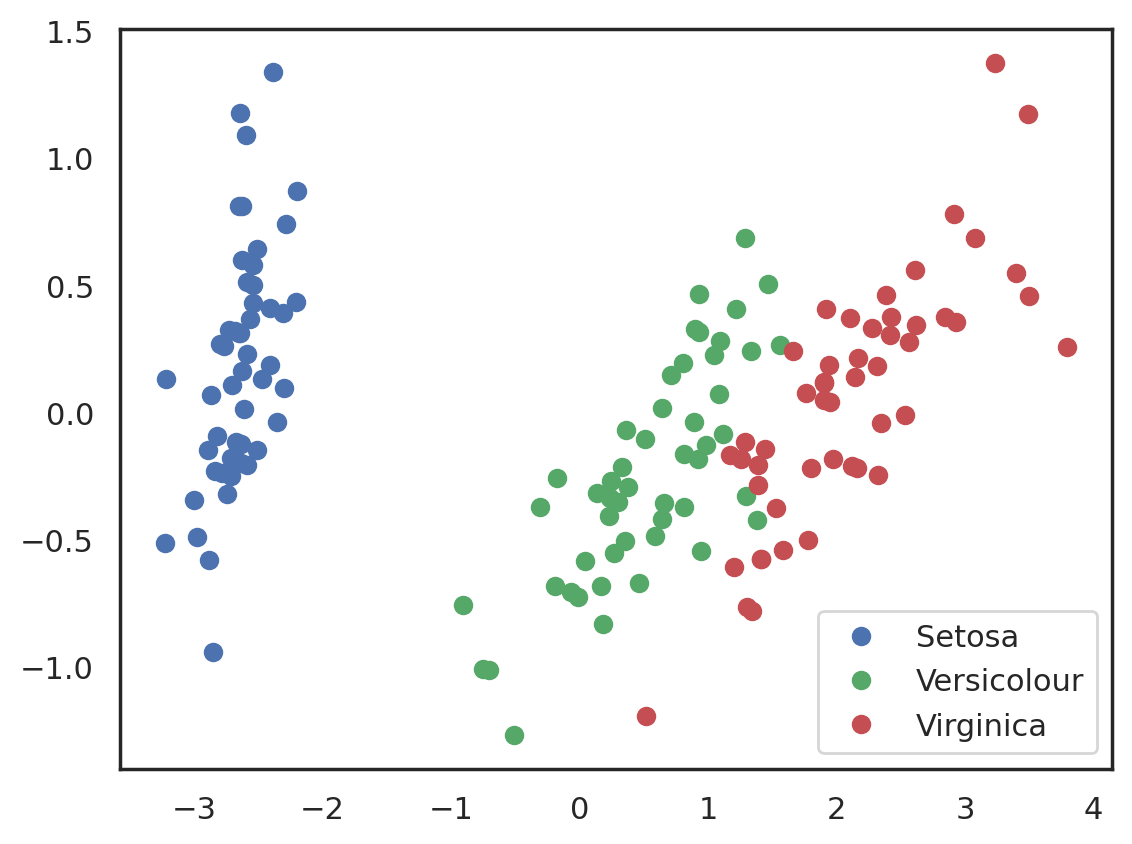

In [ ]:
# Using PCA from sklearn PCA
pca = decomposition.PCA(n_components=2)
X_centered = X - X.mean(axis=0)
pca.fit(X_centered)
X_pca = pca.transform(X_centered)

# Plotting the results of PCA
plt.plot(X_pca[y == 0, 0], X_pca[y == 0, 1], 'bo', label='Setosa')
plt.plot(X_pca[y == 1, 0], X_pca[y == 1, 1], 'go', label='Versicolour')
plt.plot(X_pca[y == 2, 0], X_pca[y == 2, 1], 'ro', label='Virginica')
plt.legend(loc=0);

In [ ]:
from sklearn import decomposition

# Test-train split and apply PCA
# Assuming X and y are already defined from previous cells.
pca = decomposition.PCA(n_components=2)
X_centered = X - X.mean(axis=0)
pca.fit(X_centered)
X_pca = pca.transform(X_centered)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=.3,
                                                    stratify=y,
                                                    random_state=42)

clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict_proba(X_test)
print('Accuracy: {:.5f}'.format(accuracy_score(y_test,
                                                preds.argmax(axis=1))))

Accuracy: 0.91111


In [ ]:
print(preds)

[[0.         0.03125    0.96875   ]
 [0.         0.89473684 0.10526316]
 [0.         0.03125    0.96875   ]
 [0.         0.89473684 0.10526316]
 [0.         0.89473684 0.10526316]
 [0.         0.03125    0.96875   ]
 [0.         0.89473684 0.10526316]
 [0.         0.89473684 0.10526316]
 [1.         0.         0.        ]
 [0.         0.03125    0.96875   ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.03125    0.96875   ]
 [0.         0.03125    0.96875   ]
 [1.         0.         0.        ]
 [0.         0.03125    0.96875   ]
 [0.         0.89473684 0.10526316]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.89473684 0.10526316]
 [1.         0.         0.        ]
 [0.         0.89473684 0.10526316]
 [0.         0.03125    0.96875   ]
 [0.         0.89473684 0.10526316]
 [0.         0.89473684 0.10526316]
 [0.         0.89473684 0.10526316]
 [0.         0.89473684 0.10

In [ ]:
preds.shape

(45, 3)

## print out the y test data

In [ ]:
import pandas as pd
df = pd.DataFrame(y_test, columns=["predictor"])
df.to_csv('/content/drive/MyDrive/Colab Notebooks/UCI/UCI_427.62_Python_for_Data_Analysis/Outputs/wcss_cp.csv', index=False)


---

# Additional Students' Practice and Answer Key

These practice questions are designed for undergraduate students. Try the **Student Practice** cell first, then compare your work with the **Completed Answer** cell.


## Student Practice 1: K-Means Clustering
Use the Iris dataset and fit a K-Means model with 3 clusters.

## Student Practice 2: Review Cluster Labels
Add the cluster labels to the DataFrame and display the first five rows.

In [ ]:
# Completed Answer: K-Means Practice
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X['cluster'] = kmeans.fit_predict(X)

display(X.head())
print('Cluster counts:')
print(X['cluster'].value_counts().sort_index())